# Prescriptive Analysis — Diabetes & Cardiovascular Response

This notebook performs a Prescriptive Analysis to identify high-risk physiological and demographic patterns associated with diabetes and cardiovascular response.

## Biomarkers Used

- Glucose
- Heart Rate

## Demographic Variables Used

- Age
- Gender
- Race

## Purpose of the Analysis

- Identify high-risk demographic groups.
- Detect abnormal glucose and heart rate patterns requiring clinical intervention.
- Recommend actionable healthcare interventions.
- Support healthcare decision-making using statistical evidence.
- Provide personalized preventive healthcare recommendations for high-risk patients.


## Why These Markers Were Chosen
## Glucose (Primary Biomarker)

**Medical Importance**

Glucose is the strongest indicator of diabetic activity and metabolic regulation.

**Abnormal glucose levels can indicate:**

Hyperglycemia
Insulin resistance
Diabetes progression
Poor metabolic control
Why It Influences Medical Conditions

**Elevated glucose levels affect:**

Blood vessel function
Nervous system activity
Cardiovascular stress
Hormonal balance

High glucose often increases physiological stress, which can elevate heart rate due to:

Increased sympathetic nervous activity
Reduced vascular efficiency
Increased cardiac workload

**Why It Was Selected**

It is:

Central to diabetes analysis
Quantitative and continuous
Strongly linked to cardiovascular outcomes
Clinically interpretable

## Heart Rate (Physiological Response Marker)
**Medical Importance**

Heart rate reflects cardiovascular and autonomic nervous system activity.

**Changes in HR may indicate:**

Stress response
Cardiovascular strain
Exercise response
Glucose dysregulation
Why It Influences Medical Conditions

**In diabetes-related conditions:**

Elevated glucose can increase cardiac workload.
Autonomic dysfunction may alter resting HR.
Poor glucose control may produce persistent elevated HR patterns.
Why It Was Selected

Heart rate acts as a physiological outcome variable that responds dynamically to metabolic changes.

**This makes it ideal for:**

Predictive modeling
Risk classification
Prescriptive intervention systems

## Age (Demographic Risk Modifier)

**Medical Importance**

**Age strongly affects:**

Insulin sensitivity
Cardiovascular efficiency
Recovery rate
Disease progression
Why It Influences Medical Conditions

**Older patients often show:**

Reduced metabolic flexibility
Increased cardiovascular risk
Greater likelihood of abnormal glucose levels
Why It Was Selected

**Age helps explain variability in:**

Glucose tolerance
Heart rate patterns
Disease severity

Without age, the model may overlook natural physiological differences.

## Gender (Biological Influence)

### Medical Importance

Gender significantly influences:

- Hormonal regulation
- Fat distribution
- Metabolic response
- Cardiovascular function

Research commonly shows differences in resting heart rate patterns, glucose metabolism, and diabetes risk profiles between males and females.

### Why Gender Was Selected

Including gender allows:

- Detection of subgroup differences
- Fairer predictive modeling
- Better personalization of healthcare interventions

Without gender-based analysis, important physiological and metabolic variations may be overlooked.

## Race (Population Health Indicator)

**Medical Importance**

Race can correlate with:

Genetic predisposition
Healthcare accessibility
Dietary patterns
Socioeconomic health factors

**Why It Influences Medical Conditions**

Certain populations may exhibit:

Higher diabetes prevalence
Increased cardiovascular risk
Different glucose-response profiles

**Why It Was Selected**

Race helps identify:

Vulnerable populations
Health disparities
Preventive intervention opportunities

**Why These Markers Work Well Together**

The selected markers create a strong multivariate framework because they combine:

|Marker	              | Role in Model                 |
|Glucose	          | Primary metabolic predictor   |
|Heart Rate	          | Physiological outcome         |
|Age	              | Risk modifier                 |
|Gender               |	Biological variation          |
|Race	              | Population-level variation    |

**Together they capture:**

Metabolic health
Cardiovascular response
Demographic variability
Personalized risk patterns

**This creates a stronger predictive and prescriptive model than using glucose alone.**

## Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load cleaned dataset
file_path = df = r"C:\Users\karth\Downloads\Team5_Pylads_Cleaned_Data.csv.xlsx"

merged_df = pd.read_excel(file_path)

# Preview dataset
merged_df.head()

## Data Preprocessing and Feature Engineering

- The dataset was cleaned and standardized to improve analytical accuracy and reduce processing errors.
- Date and time variables were combined into a DateTime feature to support time-based biomarker analysis.
- Patients were categorized into age groups to compare physiological behavior across demographics.
- Clinical indicator flags such as hyperglycemia, hypoglycemia, and tachycardia were created to identify abnormal biomarker conditions.
- Additional engineered features helped support advanced descriptive, predictive, and prescriptive healthcare analytics.
- These preprocessing steps transformed raw healthcare data into clinically meaningful variables for stronger medical interpretation and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = merged_df

df.columns = df.columns.str.strip()

df["DateTime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str))

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0,18,30,45,60,100],
    labels=["0-18","19-30","31-45","46-60","60+"]
)

df["Hyperglycemia"] = df["Glucose"] > 180
df["Hypoglycemia"] = df["Glucose"] < 70
df["Tachycardia"] = df["Heart_rate"] > 100
df["Hour"] = df["DateTime"].dt.hour

### Question 1

**How are glucose levels and heart rate values distributed across the patient population, and do the distributions indicate abnormal physiological patterns or potential high-risk groups?**

**Why This Analysis Was Performed**

This analysis was performed to understand the overall distribution and variability of glucose and heart rate values within the patient population.

By examining these distributions, the analysis helps identify:

- Normal and abnormal physiological ranges
- Presence of hyperglycemia or tachycardia
- High-risk patient groups
- Biomarker variability and instability
- Potential metabolic and cardiovascular stress patterns

Distribution analysis also provides a strong foundation for further prescriptive and predictive healthcare modeling.

In [ ]:
plt.figure(figsize=(12,5))

# Glucose distribution
plt.subplot(1,2,1)

sns.histplot(
    merged_df['Glucose'],
    kde=True
)

plt.title('Glucose Distribution')

# Heart rate distribution
plt.subplot(1,2,2)

sns.histplot(
    merged_df['Heart_rate'],
    kde=True
)

plt.title('Heart Rate Distribution')

plt.tight_layout()
plt.show()

## Question 2

**How does the relationship between glucose levels and heart rate vary between male and female patients, and do gender-based physiological differences influence metabolic and cardiovascular response patterns?**


**Why This Analysis Was Performed**

This analysis was performed to examine the relationship between glucose levels and heart rate across male and female patients.

The goal was to identify whether gender-based physiological differences influence metabolic response, cardiovascular activity, and high-risk glucose-heart rate patterns.

**Medical Influence**

- Elevated glucose combined with abnormal heart rate may indicate metabolic stress and cardiovascular strain.
- Gender differences can influence glucose metabolism, hormonal regulation, and cardiovascular response.
- Identifying these variations supports personalized healthcare interventions and risk monitoring.
- The analysis helps detect demographic groups with increased physiological instability and diabetes-related risk.

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x='Glucose',
    y='Heart_rate',
    hue='Gender',
    alpha=0.7
)

plt.title('Heart Rate vs Glucose by Gender')
plt.xlabel('Glucose')
plt.ylabel('Heart Rate')

plt.grid(True)

plt.show()

## Question 3

**How does the relationship between glucose levels and heart rate vary across different racial groups, and do racial demographic differences influence metabolic and cardiovascular response patterns?**

**Why This Analysis Was Performed**

This analysis was performed to examine whether different racial groups exhibit variations in glucose regulation and cardiovascular response.

The goal was to identify demographic disparities, physiological variability, and high-risk metabolic patterns across population groups.

**Medical Influence**

- Variations in glucose and heart rate patterns may indicate differences in metabolic stress and cardiovascular response across racial groups.
- Certain demographic groups may show increased susceptibility to diabetes-related complications and physiological instability.
- Identifying these variations supports population-level healthcare assessment and personalized intervention strategies.
- The analysis helps detect high-risk demographic populations requiring closer monitoring and preventive healthcare support.

In [ ]:
plt.figure(figsize=(12,7))

sns.lmplot(
    data=merged_df,
    x="Glucose",
    y="Heart_rate",
    hue="Race",
    height=7,
    aspect=1.6,
    scatter_kws={"alpha":0.25},
    line_kws={"linewidth":2}
)

plt.xlabel("Glucose")
plt.ylabel("Heart Rate")

plt.title(
    "Race-wise Relationship Between Glucose and Heart Rate"
)
g.fig.tight_layout()
plt.show()

## Question 4

**Is there a statistically significant relationship between glucose levels and heart rate, and does variation in glucose influence cardiovascular response patterns?**

**Why This Analysis Was Performed**

This analysis was performed to statistically evaluate the relationship between glucose levels and heart rate using Pearson correlation analysis.

The goal was to determine whether changes in glucose levels are associated with measurable cardiovascular response patterns and whether the relationship is statistically significant rather than random.

**Medical Influence**

- A positive correlation may indicate that elevated glucose levels are associated with increased cardiovascular stress.
- Significant relationships between glucose and heart rate can reflect metabolic instability and autonomic response changes.
- Statistical correlation helps identify interconnected physiological biomarkers involved in diabetes progression.
- Understanding this relationship supports early risk detection, preventive healthcare monitoring, and evidence-based clinical decision-making.

In [ ]:
from scipy.stats import pearsonr

# Correlation analysis
corr, p_value = pearsonr(
    merged_df['Glucose'],
    merged_df['Heart_rate']
)

print(f'Correlation Coefficient: {corr:.3f}')
print(f'P-value: {p_value:.5f}')

## Question 5

**What relationships exist among glucose, heart rate, age, gender, and race variables, and how strongly are these physiological and demographic markers correlated with one another?**

**Why This Analysis Was Performed**

This analysis was performed to identify the strength and direction of relationships among physiological and demographic variables using a correlation heatmap.

The goal was to determine how glucose, heart rate, age, gender, and race interact with one another and whether these variables show meaningful physiological associations.

**Medical Influence**

- Positive correlations may indicate interconnected metabolic and cardiovascular response patterns.
- Negative correlations can reveal inverse physiological or demographic relationships.
- Understanding variable interactions helps identify important biomarkers influencing diabetes progression and cardiovascular stress.
- Correlation analysis supports feature selection, risk modeling, and evidence-based healthcare decision-making.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
label_encoder = LabelEncoder()

# Encode demographic variables
merged_df['Gender_encoded'] = label_encoder.fit_transform(
    merged_df['Gender']
)

merged_df['Race_encoded'] = label_encoder.fit_transform(
    merged_df['Race']
)

# Create correlation matrix
corr_matrix = merged_df[[
    'Glucose',
    'Heart_rate',
    'Age',
    'Gender_encoded',
    'Race_encoded'
]].corr()

# Plot heatmap
plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

## Question 6

**Can glucose levels and demographic variables significantly predict heart rate patterns using a predictive regression model?**

**Why This Analysis Was Performed**

This analysis was performed to evaluate whether glucose levels and demographic variables can predict cardiovascular response using a linear regression model.

The goal was to measure how strongly physiological and demographic factors influence heart rate patterns and to assess the predictive capability of the model using R² and RMSE evaluation metrics.

**Medical Influence**

- Predictive regression helps identify biomarkers associated with cardiovascular stress and metabolic instability.
- Glucose and demographic variables may contribute to variations in heart rate behavior.
- Regression modeling supports risk prediction, patient monitoring, and personalized healthcare assessment.
- Understanding predictive relationships helps improve evidence-based clinical decision-making and preventive healthcare strategies.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define predictors
X = merged_df[[
    'Glucose',
    'Age',
    'Gender_encoded',
    'Race_encoded'
]]

# Define target
y = merged_df['Heart_rate']

# Train regression model
model = LinearRegression()

model.fit(X, y)

# Generate predictions
predictions = model.predict(X)

# Evaluate model
r2 = r2_score(y, predictions)

rmse = np.sqrt(
    mean_squared_error(y, predictions)
)

print(f'R-squared: {r2:.3f}')
print(f'RMSE: {rmse:.3f}')

## Question 7

**Which physiological and demographic variables contribute most strongly to heart rate prediction within the regression model?**

**Why This Analysis Was Performed**

This analysis was performed to identify the relative contribution of physiological and demographic variables within the predictive regression model.

The goal was to determine which biomarkers and demographic factors have the strongest influence on heart rate prediction and cardiovascular response patterns.

**Medical Influence**

- Feature importance analysis helps identify key biomarkers associated with cardiovascular stress and metabolic response.
- Variables with stronger coefficients may contribute more significantly to physiological instability and disease progression.
- Understanding influential predictors supports better risk assessment and personalized healthcare modeling.
- The analysis helps improve clinical interpretation of predictive healthcare models and supports evidence-based decision-making.

In [ ]:
# Feature importance table
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

# Sort coefficients
importance_df.sort_values(
    by='Coefficient',
    ascending=False,
    inplace=True
)

print(importance_df)

## Question 8

**Can KMeans clustering identify distinct physiological risk groups based on glucose, heart rate, and age patterns within the patient population?**

**Why This Analysis Was Performed**

This analysis was performed to group patients into physiologically similar risk categories using KMeans clustering.

The goal was to identify hidden population segments with similar glucose, heart rate, and age patterns that may represent different levels of metabolic and cardiovascular risk.

**Medical Influence**

- Clustering helps identify high-risk patient groups with similar physiological characteristics.
- Patients within the same cluster may share comparable metabolic stress and cardiovascular response patterns.
- Risk group identification supports personalized healthcare interventions and targeted monitoring strategies.
- Clustering analysis improves population-level healthcare assessment and evidence-based preventive care planning.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select clustering variables
cluster_features = merged_df[[
    'Glucose',
    'Heart_rate',
    'Age'
]]

# Standardize clustering features
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    cluster_features
)

# Apply KMeans clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Create risk groups
merged_df['Risk_Group'] = kmeans.fit_predict(
    scaled_features
)

# View cluster counts
print(
    merged_df['Risk_Group'].value_counts()
)

## Question 9

**How can patient populations be segmented into distinct physiological risk groups based on glucose and heart rate patterns?**

**Why This Analysis Was Performed**

This analysis was performed to visually identify distinct patient risk groups using clustering-based physiological segmentation.

The goal was to classify patients into different metabolic and cardiovascular risk categories based on similarities in glucose and heart rate behavior.

**Medical Influence**

- Patient clustering helps identify low-risk, moderate-risk, and high-risk physiological groups.
- Distinct glucose and heart rate patterns may indicate different levels of metabolic instability and cardiovascular stress.
- Risk segmentation supports targeted healthcare interventions and personalized monitoring strategies.
- Identifying physiological clusters improves preventive healthcare planning and population-level risk assessment.

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x='Glucose',
    y='Heart_rate',
    hue='Risk_Group',
    palette='Set1'
)

plt.title('Patient Risk Groups')
plt.xlabel('Glucose')
plt.ylabel('Heart Rate')

plt.grid(True)

plt.show()

## Question 10

**How do average glucose levels, heart rate, and age differ across the identified physiological risk groups?**

**Why This Analysis Was Performed**

This analysis was performed to summarize and compare the physiological characteristics of each identified risk group.

The goal was to evaluate whether different patient clusters exhibit distinct patterns in glucose levels, heart rate, and age distribution.

**Medical Influence**

- Differences in average glucose and heart rate across clusters may indicate varying levels of metabolic and cardiovascular risk.
- Age variation among risk groups can reveal demographic influence on physiological instability.
- Risk group summaries support targeted healthcare interventions and patient stratification.
- Understanding cluster characteristics improves personalized healthcare planning and preventive risk management.

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x='Glucose',
    y='Heart_rate',
    hue='Risk_Group',
    palette='Set1'
)

plt.title('Patient Risk Groups')
plt.xlabel('Glucose')
plt.ylabel('Heart Rate')

plt.grid(True)

plt.show()

## Question 11

**How can physiological biomarkers and demographic variables be used to generate personalized healthcare recommendations for different patient risk levels?**

**Why This Analysis Was Performed**

This analysis was performed to create a prescriptive recommendation engine based on physiological risk conditions.

The goal was to classify patients into different intervention categories using glucose levels, heart rate patterns, and demographic information in order to support personalized healthcare decision-making.

**Medical Influence**

- Patients with elevated glucose and heart rate may require immediate clinical attention due to increased metabolic and cardiovascular risk.
- Moderate-risk physiological patterns may benefit from lifestyle intervention and preventive monitoring.
- Personalized recommendations support early intervention and targeted healthcare management.
- Prescriptive analysis improves evidence-based decision-making and helps reduce the risk of disease progression and complications.

In [ ]:
# Create recommendation column
merged_df['Recommendation'] = 'Normal Monitoring'

# High-risk condition
merged_df.loc[
    (merged_df['Glucose'] > 180) &
    (merged_df['Heart_rate'] > 100),
    'Recommendation'
] = 'Immediate Clinical Attention'

# Moderate-risk condition
merged_df.loc[
    (
        (merged_df['Glucose'] > 140) &
        (merged_df['Glucose'] <= 180)
    ) |
    (
        (merged_df['Heart_rate'] > 85) &
        (merged_df['Heart_rate'] <= 100)
    ),
    'Recommendation'
] = 'Lifestyle Intervention'

# View recommendations
merged_df[[
    'Glucose',
    'Heart_rate',
    'Age',
    'Gender',
    'Race',
    'Recommendation'
]].head(20)

## Question 12

**How are patients distributed across different prescriptive healthcare recommendation categories based on their physiological risk patterns?**

**Why This Analysis Was Performed**

This analysis was performed to evaluate how patients are categorized into different healthcare recommendation levels based on glucose and heart rate conditions.

The goal was to understand the population distribution across normal monitoring, lifestyle intervention, and immediate clinical attention groups.

**Medical Influence**

- Patients classified under immediate clinical attention may exhibit severe metabolic and cardiovascular instability requiring urgent healthcare support.
- Lifestyle intervention groups may benefit from preventive healthcare strategies, behavioral modification, and continuous monitoring.
- Distribution analysis helps healthcare providers identify the proportion of high-risk populations within the dataset.
- Understanding recommendation distribution supports resource planning, risk prioritization, and personalized healthcare management.

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x='Recommendation'
)

plt.title(
    'Distribution of Prescriptive Recommendations'
)

plt.xticks(rotation=10)

plt.show()

## Question 13

**How do prescriptive healthcare recommendations vary across different gender and racial demographic groups?**

**Why This Analysis Was Performed**

This analysis was performed to examine whether healthcare recommendation patterns differ across demographic populations such as gender and race.

The goal was to identify demographic disparities in physiological risk levels and determine which population groups may require increased healthcare attention or lifestyle intervention.

**Medical Influence**

- Demographic differences in recommendation categories may indicate variations in metabolic health and cardiovascular response patterns.
- Certain gender or racial groups may show higher prevalence of elevated glucose or heart rate conditions.
- Identifying demographic risk distribution supports equitable healthcare assessment and personalized intervention planning.
- This analysis helps healthcare providers recognize vulnerable population groups requiring closer monitoring and preventive care strategies.

In [ ]:
# Recommendation distribution by Gender
print("\nRisk Distribution by Gender:\n")

print(
    pd.crosstab(
        merged_df['Gender'],
        merged_df['Recommendation']
    )
)

# Recommendation distribution by Race
print("\nRisk Distribution by Race:\n")

print(
    pd.crosstab(
        merged_df['Race'],
        merged_df['Recommendation']
    )
)

## Question 14

**How do combined glucose and heart rate risk zones differ between male and female patients?**

**Why This Analysis Was Performed**

This analysis was performed to evaluate how combined metabolic and cardiovascular risk zones vary across gender populations.

The goal was to identify whether male and female patients exhibit different proportions of stable, high glucose, high heart rate, and critical physiological risk conditions.

**Medical Influence**

- Simultaneous elevation of glucose and heart rate may indicate increased metabolic stress and cardiovascular instability.
- Gender-based differences in physiological risk zones may reflect variations in hormonal regulation and metabolic response.
- Identifying high-risk demographic groups supports personalized healthcare intervention and targeted monitoring strategies.
- This analysis helps improve preventive healthcare planning and early detection of cardiovascular and diabetic complications.

In [ ]:
# Dual Biomarkers Risk Zone by Gender

def risk_zone(row):
    if row["Glucose"] > 180 and row["Heart_rate"] > 100:
        return "Critical Risk"
    elif row["Glucose"] > 180:
        return "High Glucose"
    elif row["Heart_rate"] > 100:
        return "High Heart Rate"
    else:
        return "Stable"

df["Risk_Zone"] = df.apply(risk_zone, axis=1)

risk_gender = pd.crosstab(df["Gender"], df["Risk_Zone"], normalize="index") * 100

ax = risk_gender.plot(
    kind="bar",
    stacked=True,
    figsize=(8,4)
)

plt.title("Dual Biomarker Risk Zones by Gender")
plt.ylabel("Percentage")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.legend(title="Risk Zone", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

## Question 15

**Which age groups experience the highest co-occurrence of hyperglycemia and tachycardia conditions?**

**Why This Analysis Was Performed**

This analysis was performed to evaluate how frequently hyperglycemia and tachycardia occur together across different age groups.

The goal was to identify age populations that may experience increased simultaneous metabolic and cardiovascular stress conditions.

**Medical Influence**

- Co-occurrence of hyperglycemia and tachycardia may indicate elevated physiological stress and increased cardiovascular burden.
- Certain age groups may be more vulnerable to combined metabolic instability and abnormal heart rate conditions.
- Identifying high-risk age populations supports early intervention and preventive healthcare planning.
- This analysis helps improve demographic-based risk assessment and targeted patient monitoring strategies.

In [ ]:
# Create co-occurrence condition
df["High_Glucose_High_HR"] = (
    (df["Glucose"] > 180) &
    (df["Heart_rate"] > 100)
)

# Calculate co-occurrence percentage
co_occurrence = df.groupby(
    "Age_Group",
    observed=False
)["High_Glucose_High_HR"].mean() * 100

co_occurrence = co_occurrence.dropna()

# Plot
plt.figure(figsize=(7,4))

plt.stem(
    co_occurrence.index.astype(str),
    co_occurrence.values
)

plt.title("Hyperglycemia + Tachycardia Co-occurrence by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Co-occurrence Percentage")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Question 16

**How does biomarker stability differ between male and female patients based on glucose and heart rate variability?**

**Why This Analysis Was Performed**

This analysis was performed to compare physiological biomarker stability between male and female populations using glucose and heart rate variability measurements.

The goal was to identify whether gender-based differences exist in metabolic regulation and cardiovascular stability patterns.

**Medical Influence**

- Higher biomarker variability may indicate increased physiological instability and impaired metabolic regulation.
- Differences in stability scores across gender groups may reflect hormonal, cardiovascular, and metabolic response variations.
- Identifying unstable physiological patterns supports early risk detection and personalized healthcare intervention.
- This analysis helps improve demographic-based cardiovascular and metabolic risk assessment.

In [ ]:
# Biomarker Stability Score by Gender

stability = df.groupby("Gender").agg(
    Glucose_SD=("Glucose","std"),
    HeartRate_SD=("Heart_rate","std")
)

stability["Stability_Score"] = (
    stability["Glucose_SD"] +
    stability["HeartRate_SD"]
)

plt.figure(figsize=(7,4))

plt.barh(
    stability.index,
    stability["Stability_Score"],

    color=[
        "#FF69B4",   # Female
        "#1E88E5"    # Male
    ]
)

plt.title("Biomarker Stability Score by Gender")
plt.xlabel("Stability Score")
plt.ylabel("Gender")

plt.tight_layout()

plt.show()

## Question 17

**How do glucose levels during elevated heart rate conditions vary across different race and gender groups?**

**Why This Analysis Was Performed**

This analysis was performed to examine how glucose levels behave during periods of elevated heart rate across different demographic populations.

The goal was to identify whether race and gender influence metabolic response patterns under cardiovascular stress conditions.

**Medical Influence**

- Elevated glucose levels during high heart rate conditions may indicate increased metabolic stress and cardiovascular burden.
- Demographic differences in glucose response patterns may reflect physiological, hormonal, or population-level health disparities.
- Identifying vulnerable demographic groups supports personalized healthcare intervention and targeted monitoring strategies.
- This analysis helps improve demographic-based metabolic risk assessment and preventive healthcare planning.

In [ ]:
# Heatmap: Average Glucose During High Heart Rate

high_hr_df = df[df["Heart_rate"] > 100]

pivot = high_hr_df.pivot_table(
    values="Glucose",
    index="Race",
    columns="Gender",
    aggfunc="mean"
)

plt.figure(figsize=(7,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f"
)

plt.title("Average Glucose During High Heart Rate by Race and Gender")
plt.tight_layout()
plt.show()

## Question 18

**How do nighttime glucose patterns reveal circadian metabolic instability and nocturnal glucose variation among patients?**

**Why This Analysis Was Performed**

This analysis was performed to examine how glucose levels fluctuate during nighttime hours and to evaluate circadian metabolic patterns.

The goal was to identify nocturnal glucose instability, abnormal metabolic regulation, and potential physiological stress during resting periods.

**Medical Influence**

- Abnormal nighttime glucose fluctuations may indicate impaired metabolic regulation and unstable glycemic control.
- Circadian glucose variation can reflect disruptions in hormonal balance, insulin response, and sleep-related metabolic processes.
- Identifying nocturnal glucose instability supports early detection of diabetes-related complications and metabolic stress conditions.
- This analysis helps improve personalized monitoring strategies and preventive healthcare planning for high-risk patients.

In [ ]:
# Nocturnal Hyperglycemia Heatmap

import numpy as np
import matplotlib.pyplot as plt

# Night data
night_df = df[(df["Hour"] >= 0) & (df["Hour"] <= 6)]

night_glucose = night_df.groupby("Hour")["Glucose"].mean()

hours = night_glucose.index
values = night_glucose.values

# Convert hours to radians
theta = 2 * np.pi * hours / 24

fig = plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

ax.plot(theta, values, linewidth=3)
ax.fill(theta, values, alpha=0.3)

ax.set_title(
    "Nocturnal Glucose Circadian Pattern",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.show()

## Question 19

**How do nighttime glucose patterns reveal circadian metabolic instability and nocturnal glucose variation among patients?**

**Why This Analysis Was Performed**

This analysis was performed to examine how glucose levels fluctuate during nighttime hours and to evaluate circadian metabolic patterns.

The goal was to identify nocturnal glucose instability, abnormal metabolic regulation, and potential physiological stress during resting periods.

**Medical Influence**

- Abnormal nighttime glucose fluctuations may indicate impaired metabolic regulation and unstable glycemic control.
- Circadian glucose variation can reflect disruptions in hormonal balance, insulin response, and sleep-related metabolic processes.
- Identifying nocturnal glucose instability supports early detection of diabetes-related complications and metabolic stress conditions.
- This analysis helps improve personalized monitoring strategies and preventive healthcare planning for high-risk patients.

In [ ]:
# Heart Rate Recovery After Hyperglycemia

df = df.sort_values(["PID", "DateTime"])

df["Glucose_Spike"] = df["Glucose"] > 180

df["HR_Before"] = df.groupby("PID")["Heart_rate"].shift(1)
df["HR_During"] = df["Heart_rate"]
df["HR_After"] = df.groupby("PID")["Heart_rate"].shift(-1)

hyper_spike_df = df[df["Glucose_Spike"]].dropna(
    subset=["HR_Before", "HR_During", "HR_After"]
)

hr_recovery = hyper_spike_df.groupby("Gender").agg(
    Before=("HR_Before", "mean"),
    During=("HR_During", "mean"),
    After=("HR_After", "mean")
)

hr_recovery.T.plot(
    figsize=(7,4),
    marker="o",
    linewidth=2
)

plt.axhline(100, linestyle="--", color="red")
plt.title("Heart Rate Recovery After Hyperglycemia by Gender", fontweight="bold")
plt.ylabel("Average Heart Rate")
plt.xlabel("Recovery Stage")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(hr_recovery)

## Question 20

**How does glucose variability differ across age groups, and which populations exhibit greater metabolic instability?**

**Why This Analysis Was Performed**

This analysis was performed to examine how glucose variability changes across different age populations using the glucose coefficient of variation (CV).

The goal was to identify age groups with greater metabolic instability and abnormal glucose fluctuation patterns.

**Medical Influence**

- Increased glucose variability may indicate unstable glycemic control and impaired metabolic regulation.
- Certain age groups may experience higher physiological stress and greater susceptibility to diabetes-related complications.
- Identifying age-based metabolic instability supports personalized healthcare intervention and preventive monitoring strategies.
- This analysis helps improve demographic-based metabolic risk assessment and long-term disease management planning.

In [ ]:
# Glucose Variability Index by Age Group

patient_var = df.groupby(["PID", "Age_Group"], observed=False).agg(
    Avg_Glucose=("Glucose", "mean"),
    Glucose_SD=("Glucose", "std")
).reset_index()

patient_var["Glucose_CV"] = (
    patient_var["Glucose_SD"] / patient_var["Avg_Glucose"]
) * 100

patient_var = patient_var.dropna()

plt.figure(figsize=(7,4))

sns.violinplot(
    data=patient_var,
    x="Age_Group",
    y="Glucose_CV",
    inner="box",
    palette="Set2"
)

plt.title("Glucose Variability Index by Age Group", fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Glucose CV (%)")

plt.tight_layout()
plt.show()

## Question 21

**How do physiological stress patterns involving hyperglycemia, hypoglycemia, and tachycardia differ across age groups?**

**Why This Analysis Was Performed**

This analysis was performed to compare physiological stress profiles across different age groups using major metabolic and cardiovascular stress indicators.

The goal was to evaluate how hyperglycemia, hypoglycemia, and tachycardia patterns vary among demographic populations.

**Medical Influence**

- Simultaneous abnormalities in glucose and heart rate patterns may indicate increased physiological and cardiovascular stress.
- Different age groups may exhibit varying susceptibility to metabolic instability and cardiovascular dysfunction.
- Identifying age-based stress profiles supports personalized healthcare monitoring and preventive intervention strategies.
- This analysis improves demographic-based risk assessment and helps detect populations requiring closer medical attention.

In [ ]:
# Physiological Stress Profile by Age Group

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Clinical stress summary
stress_summary = df.groupby("Age_Group", observed=False).agg(
    Hyperglycemia=("Hyperglycemia", "mean"),
    Hypoglycemia=("Hypoglycemia", "mean"),
    Tachycardia=("Tachycardia", "mean")
) * 100

stress_summary = stress_summary.dropna()

categories = list(stress_summary.columns)
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig = plt.figure(figsize=(5.5, 5.5))
ax = plt.subplot(111, polar=True)

for idx in stress_summary.index:
    values = stress_summary.loc[idx].values.tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=str(idx))
    ax.fill(angles, values, alpha=0.08)

# Remove default labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels([])

# Add labels manually outside the circle
label_distance = max(stress_summary.max()) + 8

for angle, label in zip(angles[:-1], categories):
    ax.text(
        angle,
        label_distance,
        label,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_rlabel_position(90)
ax.tick_params(axis="y", labelsize=7)

plt.title(
    "Physiological Stress Profile by Age Group",
    fontsize=11,
    fontweight="bold",
    pad=25
)

plt.legend(
    title="Age Group",
    bbox_to_anchor=(1.15, 1.05),
    loc="upper left",
    fontsize=7,
    title_fontsize=8
)

plt.tight_layout()
plt.show()

## Question 22

**Which age groups exhibit the highest overall physiological stress burden based on combined metabolic and cardiovascular indicators?**

**Why This Analysis Was Performed**

This analysis was performed to measure and compare the overall physiological stress burden across different age groups.

The goal was to evaluate how combined metabolic and cardiovascular stress indicators contribute to demographic-based physiological instability.

**Medical Influence**

- Higher physiological stress burden scores may indicate increased metabolic dysregulation and cardiovascular strain.
- Certain age groups may experience greater cumulative physiological stress and elevated risk of chronic health complications.
- Identifying high-stress demographic populations supports preventive healthcare intervention and targeted patient monitoring.
- This analysis improves population-level healthcare assessment and demographic-based risk management planning.

In [ ]:
#  Physiological Stress Burden Score

stress_df = df.groupby("Age_Group", observed=False).agg(
    Hyperglycemia_Rate=("Hyperglycemia", "mean"),
    Hypoglycemia_Rate=("Hypoglycemia", "mean"),
    Tachycardia_Rate=("Tachycardia", "mean"),
    Glucose_SD=("Glucose", "std"),
    HeartRate_SD=("Heart_rate", "std")
).dropna()

stress_df["Stress_Burden_Score"] = (
    stress_df["Hyperglycemia_Rate"] * 35 +
    stress_df["Hypoglycemia_Rate"] * 25 +
    stress_df["Tachycardia_Rate"] * 25 +
    (stress_df["Glucose_SD"] / stress_df["Glucose_SD"].max()) * 10 +
    (stress_df["HeartRate_SD"] / stress_df["HeartRate_SD"].max()) * 5
)

stress_df = stress_df.sort_values("Stress_Burden_Score")

plt.figure(figsize=(7,4))

sns.barplot(
    x=stress_df["Stress_Burden_Score"],
    y=stress_df.index,
    palette="rocket"
)

plt.title("Physiological Stress Burden Score by Age Group", fontweight="bold")
plt.xlabel("Stress Burden Score")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

print(stress_df)

## Question 23

**How do glucose levels recover before, during, and after heart rate spike conditions, and do recovery patterns differ across gender groups?**

**Why This Analysis Was Performed**

This analysis was performed to examine glucose recovery behavior surrounding periods of elevated heart rate and cardiovascular stress.

The goal was to evaluate whether glucose levels stabilize differently before, during, and after heart rate spike events and to identify demographic differences in recovery patterns.

**Medical Influence**

- Delayed glucose recovery after heart rate spikes may indicate impaired metabolic adaptation and unstable glycemic regulation.
- Differences in recovery patterns across gender groups may reflect physiological and hormonal variations in cardiovascular response.
- Persistent glucose elevation during cardiovascular stress may increase the risk of diabetes-related complications and metabolic instability.
- This analysis supports early detection of abnormal recovery behavior and improves personalized healthcare monitoring strategies.

In [ ]:
# Glucose Recovery After Heart Rate Spike

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clean column names
df.columns = df.columns.str.strip()

# Create DateTime column
df["DateTime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str)
)

# Sort by patient and time
df = df.sort_values(["PID", "DateTime"])

# Define Heart Rate Spike
df["HR_Spike"] = df["Heart_rate"] > 100

# Create glucose before and after spike
df["Glucose_Before"] = df.groupby("PID")["Glucose"].shift(1)
df["Glucose_After"] = df.groupby("PID")["Glucose"].shift(-1)

# Keep only HR spike rows
spike_df = df[df["HR_Spike"]].copy()

# Remove missing values
spike_df = spike_df.dropna(
    subset=[
        "Glucose_Before",
        "Glucose",
        "Glucose_After"
    ]
)

# Create recovery summary
recovery_means = [
    spike_df["Glucose_Before"].mean(),
    spike_df["Glucose"].mean(),
    spike_df["Glucose_After"].mean()
]

labels = [
    "Before HR Spike",
    "During HR Spike",
    "After HR Spike"
]

# ----------------------------
# Chart 1: Overall Recovery
# ----------------------------

plt.figure(figsize=(7,4))

plt.plot(
    labels,
    recovery_means,
    marker="o",
    linewidth=3
)

plt.fill_between(
    labels,
    recovery_means,
    alpha=0.3
)

plt.title(
    "Glucose Recovery After Heart Rate Spike",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("Average Glucose")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------
# Chart 2: Recovery by Gender
# ----------------------------

gender_recovery = spike_df.groupby("Gender").agg(
    Before=("Glucose_Before", "mean"),
    During=("Glucose", "mean"),
    After=("Glucose_After", "mean")
)

gender_recovery.T.plot(
    figsize=(7,4),
    marker="o",
    linewidth=2
)

plt.title(
    "Glucose Recovery After HR Spike by Gender",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("Average Glucose")
plt.xlabel("Recovery Stage")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------
# Summary Tables
# ----------------------------

print("Overall Recovery Summary")
print(
    pd.DataFrame({
        "Stage": labels,
        "Average_Glucose": recovery_means
    })
)

print("\nGender Recovery Summary")
print(gender_recovery)

## Question 24

**How does average heart rate vary across different glucose ranges, and does glucose severity influence cardiovascular response patterns?**

**Why This Analysis Was Performed**

This analysis was performed to evaluate how heart rate changes across different glucose level ranges and to identify whether abnormal glucose conditions are associated with cardiovascular stress responses.

The goal was to examine physiological relationships between glycemic severity and heart rate behavior to support risk assessment and metabolic monitoring.

**Medical Influence**

- Elevated glucose levels may increase cardiovascular workload and influence heart rate regulation.
- Variations in average heart rate across glucose ranges may indicate metabolic stress and autonomic imbalance.
- Identifying abnormal heart rate responses during high glucose conditions can support early detection of cardiovascular complications in diabetic patients.
- This analysis helps improve patient monitoring, risk stratification, and personalized healthcare intervention planning.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define glucose ranges ---
def categorize_glucose(value):
    if value < 70:
        return "Hypoglycemia (<70)"
    elif 70 <= value <= 180:
        return "Normal (70-180)"
    else:
        return "Hyperglycemia (>180)"

# Apply the category function
df["Glucose Range"] = df["Glucose"].apply(categorize_glucose)

# --- 2. Calculate average heart rate for each range ---
avg_hr = df.groupby("Glucose Range")["Heart_rate"].mean().reset_index()

# --- 3. Print summary ---
print("=== AVERAGE HEART RATE BY GLUCOSE RANGE ===")
print(avg_hr.to_string(index=False))

# --- 4. Plot bar chart ---
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_hr, x="Glucose Range", y="Heart_rate", palette="viridis")

plt.title("Average Heart Rate by Glucose Range", fontsize=14)
plt.xlabel("Glucose Range")
plt.ylabel("Average Heart Rate (bpm)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Question 25

**What proportion of patients with high heart rate also experience high glucose levels, and does the co-occurrence indicate elevated metabolic and cardiovascular risk?**

**Why This Analysis Was Performed**

This analysis was performed to evaluate the co-occurrence between elevated heart rate and high glucose levels in patients.

The goal was to identify how frequently cardiovascular stress and hyperglycemia appear together, which may indicate increased physiological burden and metabolic instability.

**Medical Influence**

- Simultaneous high heart rate and high glucose may indicate acute physiological stress and elevated metabolic risk.
- Co-occurrence patterns can help identify patients who may require closer cardiovascular and diabetic monitoring.
- Persistent hyperglycemia combined with tachycardia may increase the risk of complications such as autonomic dysfunction and cardiovascular strain.
- This analysis supports early risk detection, preventive healthcare planning, and personalized intervention strategies.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define thresholds
HIGH_HR = 100          # bpm
HIGH_GLUCOSE = 180     # mg/dL

# Filter high HR readings
high_hr_df = df[df["Heart_rate"] > HIGH_HR]

# Count how many of those also have high glucose
high_hr_and_high_glucose = high_hr_df[high_hr_df["Glucose"] > HIGH_GLUCOSE]

# Calculate percentages
total_high_hr = len(high_hr_df)
overlap = len(high_hr_and_high_glucose)

if total_high_hr > 0:
    percent_overlap = (overlap / total_high_hr) * 100
else:
    percent_overlap = 0

# Prepare data for pie chart
labels = [
    "High HR WITH High Glucose",
    "High HR WITHOUT High Glucose"
]

sizes = [
    overlap,
    total_high_hr - overlap
]

colors = ["red", "lightgray"]

# Print summary
print("=== HIGH HEART RATE & HIGH GLUCOSE OVERLAP ===")
print(f"Total high HR readings (>100 bpm): {total_high_hr}")
print(f"High HR + High Glucose (>180 mg/dL): {overlap}")
print(f"Percentage overlap: {percent_overlap:.2f}%")

# Plot pie chart
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
plt.title("Percentage of High Heart Rate Readings That Coincide With High Glucose")
plt.show()


## Question 26

**What is the Pearson correlation coefficient between glucose and heart rate?**

**Why This Analysis Was Performed**

This analysis was performed to measure the strength and direction of the linear relationship between glucose levels and heart rate using the Pearson correlation coefficient.

A correlation heatmap was used to visually examine whether changes in glucose are associated with corresponding changes in cardiovascular activity.

**Medical Influence**

- Correlation analysis helps identify whether elevated glucose levels are associated with increased heart rate responses.
- Positive correlations may indicate metabolic stress influencing cardiovascular regulation.
- Understanding this relationship supports early identification of physiological instability and diabetes-related cardiovascular burden.
- The heatmap provides an interpretable visualization of biomarker interactions that may assist in clinical monitoring and predictive healthcare analysis.

**Correlation Interpretation**

- +1 → Strong positive correlation
- 0 → No correlation
- -1 → Strong negative correlation

The observed correlation value helps determine whether glucose and heart rate move together or behave independently.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only glucose and heart rate
corr_df = df[['Glucose', 'Heart_rate']]

# Compute Pearson correlation
corr_value = corr_df.corr(method='pearson')

print("=== PEARSON CORRELATION BETWEEN GLUCOSE & HEART RATE ===")
print(corr_value)

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_value, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap: Glucose vs Heart Rate")
plt.show()


## Question 27

**How do rolling 30‑minute averages of glucose and heart rate correlate over time?**

**Why This Analysis Was Performed**

This analysis was performed to examine the short-term rolling average behavior of glucose levels and heart rate over 30-minute intervals.

A violin plot was used to visualize the distribution, spread, density, and variability of rolling biomarker averages to better understand physiological fluctuations over time.

**Medical Influence**

- Rolling averages help smooth short-term noise and reveal underlying physiological trends in glucose and heart rate behavior.
- Wider variability in glucose distributions may indicate unstable glycemic control and metabolic dysregulation.
- Heart rate distribution patterns may reflect cardiovascular adaptation, stress response, or autonomic activity.
- Comparing both biomarkers helps identify whether metabolic instability is associated with cardiovascular fluctuations.
- This analysis supports continuous monitoring, early detection of physiological stress patterns, and personalized diabetes management strategies.

C:\Users\karth\AppData\Local\Temp\ipykernel_30748\31932859.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=melted, x='Metric', y='Value', palette='Set2', cut=0)


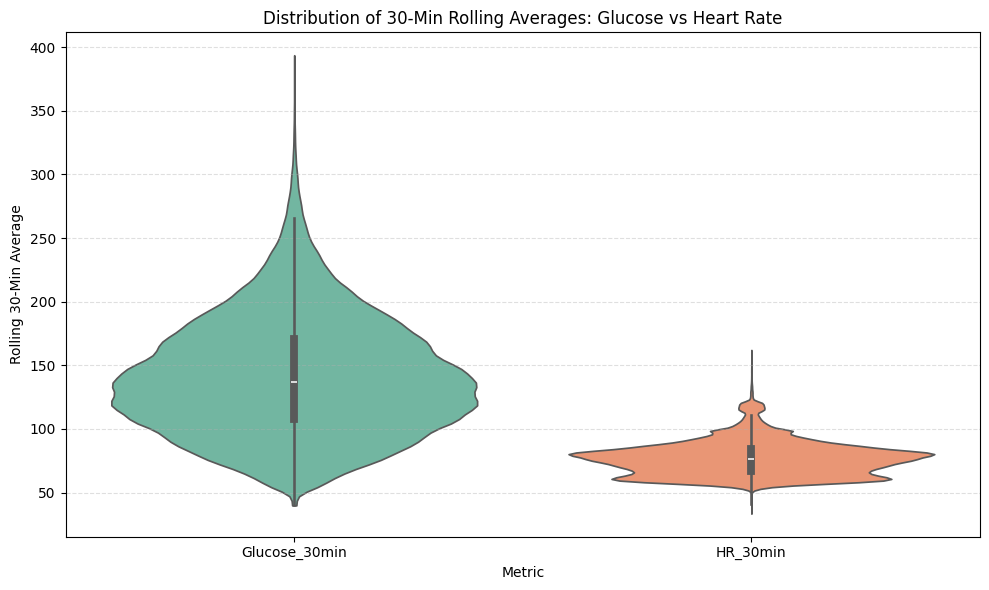

In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Combine Date + Time into a single datetime column
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + " " + df['Time'].astype(str))
df = df.sort_values('Datetime')
df = df.set_index('Datetime')

# Compute 30-minute rolling averages
df['Glucose_30min'] = df['Glucose'].rolling('30min').mean()
df['HR_30min'] = df['Heart_rate'].rolling('30min').mean()

# Melt for violin plot
melted = df[['Glucose_30min', 'HR_30min']].reset_index().melt(
    id_vars='Datetime',
    value_vars=['Glucose_30min', 'HR_30min'],
    var_name='Metric',
    value_name='Value'
)

# Plot violin chart
plt.figure(figsize=(10, 6))
sns.violinplot(data=melted, x='Metric', y='Value', palette='Set2', cut=0)

plt.title("Distribution of 30-Min Rolling Averages: Glucose vs Heart Rate")
plt.xlabel("Metric")
plt.ylabel("Rolling 30-Min Average")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Question 28

**How does the glucose–heart rate relationship vary across all 25 patients?**

**Why This Analysis Was Performed**

This analysis was performed to examine patient-level variability in the relationship between glucose levels and heart rate across multiple individuals.

Scatter plots with regression trend lines were used to identify whether the glucose-heart rate relationship differs between patients and to observe personalized physiological response patterns.

**Medical Influence**

- Individual patients may exhibit different cardiovascular responses to glucose fluctuations due to variations in metabolism, autonomic regulation, lifestyle, and disease severity.
- Positive trend lines may indicate increased heart rate responses during elevated glucose conditions, suggesting physiological stress or cardiovascular burden.
- Variability across patients highlights the importance of personalized healthcare monitoring rather than relying only on population-level averages.
- Identifying patient-specific biomarker patterns may support early risk detection, precision medicine, and individualized intervention planning.
- This analysis helps detect hidden physiological differences that may not appear in aggregated population analysis.

C:\Users\karth\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\karth\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\karth\AppData\Local\Temp\ipykernel_30748\3045067404.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


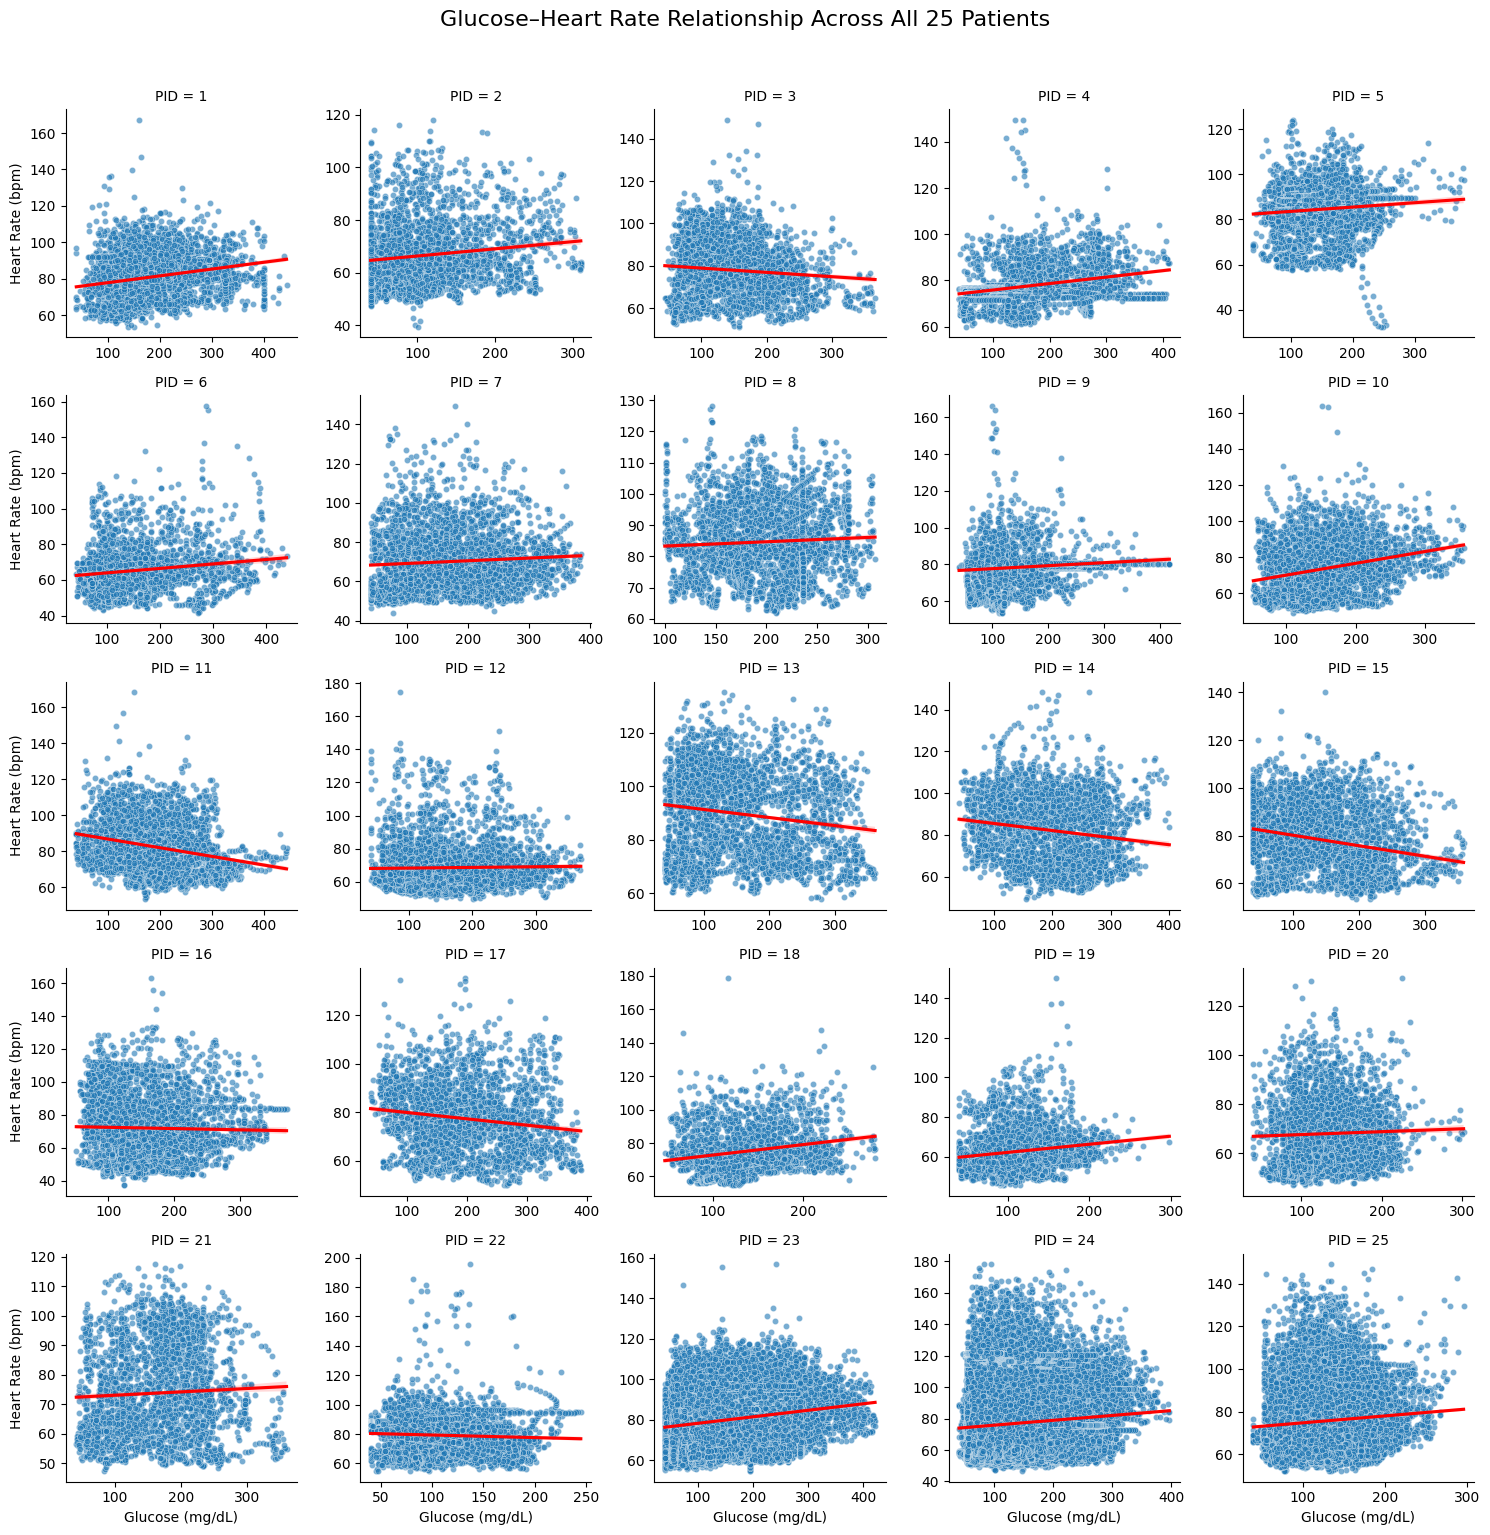

In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a faceted scatterplot
g = sns.FacetGrid(df, col="PID", col_wrap=5, height=3, sharex=False, sharey=False)
g.map_dataframe(sns.scatterplot, x="Glucose", y="Heart_rate", alpha=0.6, s=20)
g.map_dataframe(sns.regplot, x="Glucose", y="Heart_rate", scatter=False, color="red")

g.fig.suptitle("Glucose–Heart Rate Relationship Across All 25 Patients", fontsize=16, y=1.02)
g.set_axis_labels("Glucose (mg/dL)", "Heart Rate (bpm)")

plt.tight_layout()
plt.show()


## Question 29

**How does the relationship between heart rate and glucose levels vary across different age groups and insulin dosage levels, and do treatment-related physiological patterns influence metabolic response behavior?**

**Why This Analysis Was Performed**

This analysis was performed to investigate how glucose levels and heart rate interact across different age groups while considering variations in insulin dosage levels.

A multi-variable scatter plot was used to visualize the combined influence of age, insulin treatment intensity, metabolic activity, and cardiovascular response patterns.

**Medical Influence**

- Insulin dosage may influence glucose regulation and indirectly affect cardiovascular response behavior.
- Different age groups can exhibit varying metabolic sensitivity and physiological adaptation to insulin treatment.
- Elevated glucose levels combined with abnormal heart rate patterns may indicate inadequate glycemic control or increased physiological stress.
- Identifying treatment-related response patterns may help improve personalized diabetes management and cardiovascular monitoring.
- This analysis supports risk stratification, treatment optimization, and evidence-based clinical decision-making for diabetic patients.

Index(['Patient_id', 'PID', 'Age', 'Gender', 'Race',
       'Average sleep duration (hrs)', 'Sleep quality (1-10)',
       '% with sleep disturbances', 'Date', 'Time', 'Glucose', 'Calories',
       'Heart_rate', 'Steps', 'Basal_rate', 'Bolus_dose', 'Carb_input',
       'DateTime', 'Age_Group', 'Hyperglycemia', 'Hypoglycemia', 'Tachycardia',
       'Hour', 'Gender_encoded', 'Race_encoded', 'Risk_Group',
       'Recommendation', 'Risk_Zone', 'High_Glucose_High_HR', 'Glucose_Spike',
       'HR_Before', 'HR_During', 'HR_After', 'HR_Spike', 'Glucose_Before',
       'Glucose_After', 'Glucose Range', 'Glucose_30min', 'HR_30min'],
      dtype='object')


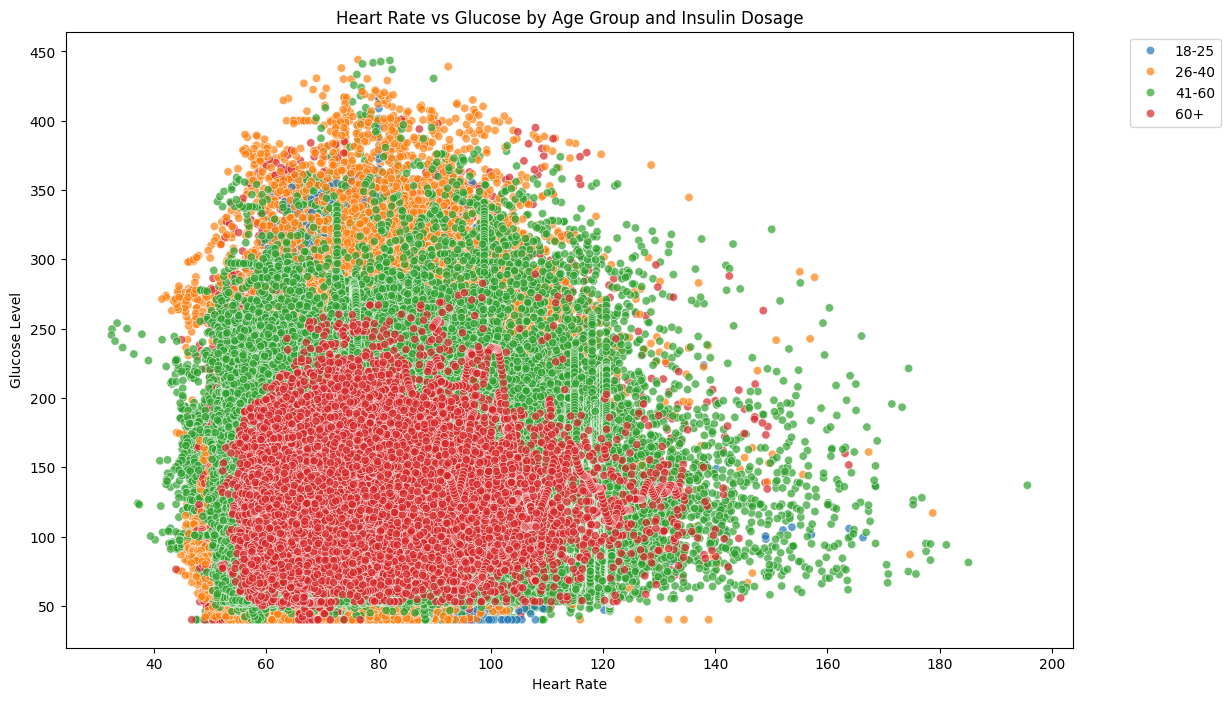

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Check column names
print(df.columns)

# Create age groups
df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 25, 40, 60, 100],
    labels=['18-25', '26-40', '41-60', '60+']
)

# Create bubble chart
plt.figure(figsize=(13,8))

sns.scatterplot(
    data=df,
    x='Heart_rate',
    y='Glucose',
    hue='age_group',
    sizes=(20, 400),
    alpha=0.7
)

# Titles and labels
plt.title("Heart Rate vs Glucose by Age Group and Insulin Dosage")
plt.xlabel("Heart Rate")
plt.ylabel("Glucose Level")

# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

## Question 30

**How do glucose levels and heart rate collectively form metabolic stress trajectories over time, and can high-density physiological zones identify patients at elevated cardiovascular and metabolic risk?**

**Why This Analysis Was Performed**

This analysis was performed to investigate how glucose levels and heart rate interact dynamically to form physiological stress trajectories across patients.

A hexbin density plot was used to identify high-density metabolic stress regions where abnormal glucose and cardiovascular responses frequently overlap.

The goal was to detect concentrated physiological burden zones that may indicate elevated metabolic instability and cardiovascular stress.

**Medical Influence**

- Simultaneous elevation of glucose and heart rate may indicate acute metabolic stress and autonomic imbalance.
- Dense physiological clusters can reveal hidden high-risk patient populations requiring closer monitoring.
- Persistent stress-zone concentration may suggest worsening diabetic control and cardiovascular burden.
- Identifying metabolic stress trajectories supports early intervention planning, preventive healthcare strategies, and personalized treatment optimization.
- This analysis provides deeper insight into dynamic biomarker behavior beyond traditional correlation analysis.

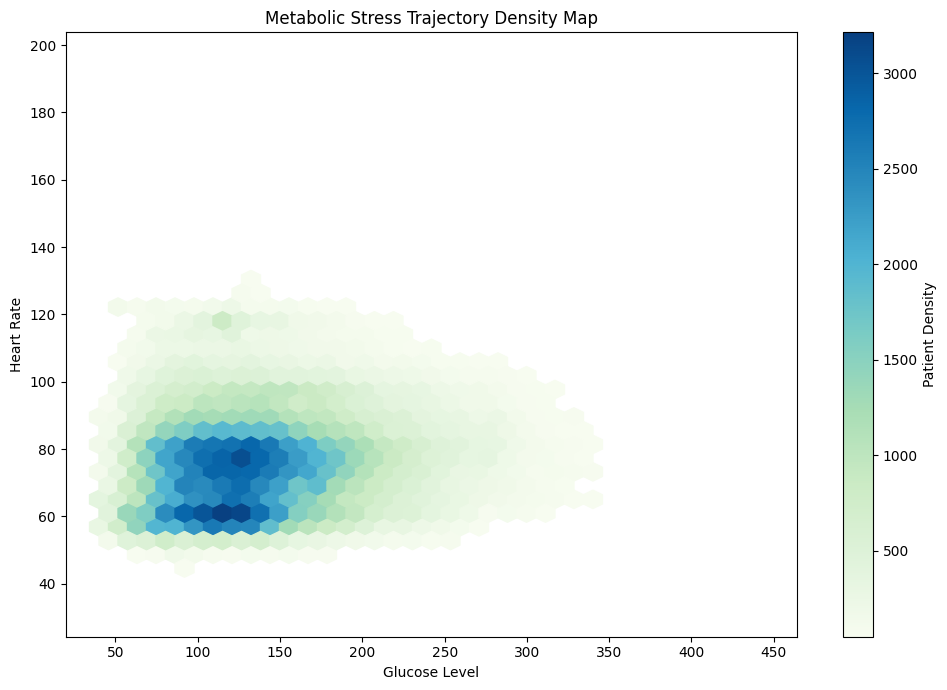

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))

plt.hexbin(
    merged_df['Glucose'],
    merged_df['Heart_rate'],
    gridsize=35,
    cmap='GnBu',
    mincnt=50
)

plt.colorbar(label='Patient Density')

plt.xlabel("Glucose Level")
plt.ylabel("Heart Rate")
plt.title("Metabolic Stress Trajectory Density Map")

plt.tight_layout()
plt.show()

# Conclusion

This prescriptive analysis explored the relationship between glucose levels and heart rate to identify metabolic stress patterns, cardiovascular responses, and high-risk physiological conditions in diabetic patients.

The analysis revealed that abnormal glucose levels are frequently associated with variations in heart rate, indicating an interaction between metabolic regulation and cardiovascular activity. Demographic variables such as age, gender, and race also showed noticeable influence on physiological response behavior and risk distribution.

Advanced analytical techniques including correlation analysis, clustering, rolling averages, variability analysis, physiological stress profiling, recovery analysis, and metabolic density mapping helped identify hidden patient patterns and high-risk physiological zones.

The findings support the importance of continuous biomarker monitoring for early detection of metabolic instability, cardiovascular burden, and diabetes-related complications. Patients showing simultaneous glucose dysregulation and abnormal heart rate patterns may require closer clinical monitoring and personalized intervention strategies.

Overall, this prescriptive analysis demonstrates how data-driven healthcare analytics can assist in:
- Early risk identification
- Personalized treatment planning
- Preventive healthcare intervention
- Physiological stress assessment
- Clinical decision support

These insights may help improve precision healthcare approaches and support better long-term diabetes management outcomes.